In [1]:
import scanpy as sc

In [2]:
import pandas as pd
import numpy as np
import anndata as ad
import os

def raman_excel_to_anndata(file_paths, wavelength_min=600, wavelength_max=1800):
    """
    将多个拉曼光谱 Excel 文件转换为一个 AnnData 对象

    参数：
        file_paths: list[str]，包含所有 Excel 文件路径
        wavelength_min: float，波长最小值
        wavelength_max: float，波长最大值

    返回：
        adata: anndata.AnnData 对象
    """
    all_data = []
    obs_names = []
    var_names = None

    for file_path in file_paths:
        # 提取文件名作为前缀
        file_prefix = os.path.splitext(os.path.basename(file_path))[0]

        # 读取 Excel 文件（不包含表头，因为第一行为列名）
        df_raw = pd.read_excel(file_path, header=None)

        # 第一列是波长
        wavelengths = df_raw.iloc[1:, 0].astype(float).values

        # 第一行是细胞名
        cell_names = df_raw.iloc[0, 1:].values.astype(str)

        # 其余为光谱强度值
        spectrum_data = df_raw.iloc[1:, 1:].astype(float).values.T  # 转置：行是细胞，列是波长

        # 波长筛选
        valid_idx = (wavelengths >= wavelength_min) & (wavelengths <= wavelength_max)
        spectrum_data = spectrum_data[:, valid_idx]
        filtered_wavelengths = wavelengths[valid_idx]

        # 保存
        all_data.append(spectrum_data)
        obs_names.extend([f"{file_prefix}_{name}" for name in cell_names])

        if var_names is None:
            var_names = filtered_wavelengths

    # 拼接所有数据
    X = np.vstack(all_data)

    # 创建 AnnData 对象
    adata = ad.AnnData(
        X=X,
        obs=pd.DataFrame(index=obs_names),
        var=pd.DataFrame(index=var_names.astype(str))  # 波长作为列名
    )

    return adata


In [4]:
# 使用示例
file_paths = [
    "./data/B-ALL/B-ALL-1-1.xlsx",
    "./data/B-ALL/B-ALL-1-2.xlsx",
    "./data/B-ALL/B-ALL-2.xlsx",
    "./data/B-ALL/B-ALL-3.xlsx",
]

adata = raman_excel_to_anndata(file_paths)

# 可视化或保存
print(adata)
# adata.write("raman_data.h5ad")

AnnData object with n_obs × n_vars = 545 × 689


g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\anndata\_core\anndata.py:1830: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
adata.X[adata.X < 0] = 0  # 修改原数组
adata.obs['cell_type'] = "ALL-preB"

In [8]:
adata.obs

,cell_type
B-ALL-1-1_1-2_Points00,ALL-preB
B-ALL-1-1_1-2_Points01,ALL-preB
B-ALL-1-1_1-2_Points02,ALL-preB
B-ALL-1-1_1-2_Points03,ALL-preB
B-ALL-1-1_1-2_Points04,ALL-preB
...,...
B-ALL-3_3-1_Points168,ALL-preB
B-ALL-3_3-1_Points169,ALL-preB
B-ALL-3_3-1_Points170,ALL-preB
B-ALL-3_3-1_Points171,ALL-preB


In [17]:
adata.write("./data/raman_ALL-preB_before_correction.h5ad")

**这里我发现波数范围和点数不同，我这里应该使用修正后的波数去进行分析！**

In [18]:
import os
import pandas as pd
import numpy as np
import anndata as ad
from pathlib import Path

def read_raman_folder_to_anndata(base_dir):
    """
    从分目录的拉曼 txt 文件读取并整理为 AnnData 对象

    参数:
        base_dir: str 或 Path，顶层目录路径，包含多个子目录和 txt 文件

    返回:
        adata: anndata.AnnData 对象
    """
    base_dir = Path(base_dir)
    spectra_list = []
    obs_names = []
    wavelengths = None

    # 遍历所有子目录
    for subdir in sorted(base_dir.iterdir()):
        if not subdir.is_dir():
            continue

        # 遍历子目录中的所有 .txt 文件
        for txt_file in sorted(subdir.glob("*.txt")):
            try:
                df = pd.read_csv(txt_file, sep="\t", header=None)
                if wavelengths is None:
                    wavelengths = df.iloc[:, 0].values  # 记录波长
                else:
                    # 检查波长一致性
                    if not np.allclose(wavelengths, df.iloc[:, 0].values, atol=1e-2):
                        raise ValueError(f"Wavelength mismatch in file: {txt_file}")

                intensity = df.iloc[:, 1].values
                spectra_list.append(intensity)

                # 以文件名去掉扩展名作为细胞名
                cell_name = txt_file.stem  # 如 1-1_Points000
                obs_names.append(cell_name)
            except Exception as e:
                print(f"⚠️ Failed to parse {txt_file}: {e}")

    # 组合成矩阵
    X = np.vstack(spectra_list)

    # 构建 AnnData
    adata = ad.AnnData(
        X=X,
        obs=pd.DataFrame(index=obs_names),
        var=pd.DataFrame(index=wavelengths.astype(str))  # 波长作为列索引
    )
    return adata


In [19]:
# 使用示例（请修改为你自己的目录路径）
adata = read_raman_folder_to_anndata("./data/修改波数处理后数据")

# 查看基本信息
print(adata)

# 可选择保存
# adata.write("raman_data.h5ad")

⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points00.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points00.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points01.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points01.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points02.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points02.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points03.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points03.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points04.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points04.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points05.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points05.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points06.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1-2_Points06.txt
⚠️ Failed to parse data\修改波数处理后数据\1-2pro\1-2_Points07.txt: Wavelength mismatch in file: data\修改波数处理后数据\1-2pro\1

In [20]:
import os
import pandas as pd
import numpy as np
import anndata as ad
from pathlib import Path

def read_raman_folder_with_reference_var(base_dir, raman_B):
    """
    使用 raman_B 的波数作为标准，读取 txt 文件并构建 AnnData 对象

    参数:
        base_dir: str 或 Path，包含子目录的顶层路径
        raman_B: AnnData，对应已有的参考波数（使用其 .var_names）

    返回:
        adata: anndata.AnnData 对象
    """
    base_dir = Path(base_dir)
    spectra_list = []
    obs_names = []
    expected_var_len = len(raman_B.var_names)
    ref_var_names = raman_B.var_names.copy()

    # 遍历子目录
    for subdir in sorted(base_dir.iterdir()):
        if not subdir.is_dir():
            continue

        for txt_file in sorted(subdir.glob("*.txt")):
            try:
                df = pd.read_csv(txt_file, sep="\t", header=None)

                # 检查点数是否一致
                if df.shape[0] != expected_var_len:
                    print(f"⚠️ 跳过 {txt_file}: 点数 {df.shape[0]} 与参考值 {expected_var_len} 不一致")
                    continue

                intensity = df.iloc[:, 1].values
                spectra_list.append(intensity)

                # 使用文件名作为细胞名
                cell_name = txt_file.stem  # 例如 1-1_Points000
                obs_names.append(cell_name)
            except Exception as e:
                print(f"⚠️ 解析失败 {txt_file}: {e}")

    # 组合矩阵
    X = np.vstack(spectra_list)

    # 创建 AnnData，统一使用 raman_B 的 var_names
    adata = ad.AnnData(
        X=X,
        obs=pd.DataFrame(index=obs_names),
        var=pd.DataFrame(index=ref_var_names)
    )
    return adata

# 使用示例：
# from your source: raman_B = ad.read_h5ad("raman_B.h5ad")  # 或已有对象
# adata = read_raman_folder_with_reference_var("path/to/raman_dir", raman_B)


In [10]:
raman_B = sc.read_h5ad("./data/raman_B.h5ad")
raman_B

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'

In [21]:
adata = read_raman_folder_with_reference_var("./data/修改波数处理后数据", raman_B)
adata

AnnData object with n_obs × n_vars = 542 × 432

In [23]:
adata.X[adata.X < 0] = 0  # 修改原数组
adata.obs['cell_type'] = "ALL-preB"
adata.write("./data/raman_ALL-preB.h5ad")

In [24]:
concat_ad = ad.concat([adata,raman_B])
concat_ad

AnnData object with n_obs × n_vars = 1957 × 432
    obs: 'cell_type'

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


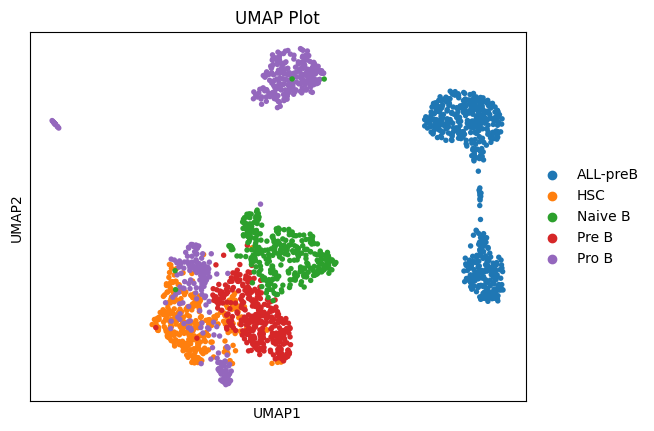

In [25]:
concat_ad.layers['raw'] = concat_ad.X.copy()
# 数据归一化 (Normalization)
sc.pp.normalize_total(concat_ad, target_sum=1e4)
sc.pp.log1p(concat_ad)
concat_ad.layers['norm'] = concat_ad.X.copy()
# 数据标准化 (scale)
sc.pp.scale(concat_ad)

# PCA 降维
sc.tl.pca(concat_ad, svd_solver='arpack')

# UMAP 降维
sc.pp.neighbors(concat_ad, n_neighbors=10, n_pcs=20)
sc.tl.umap(concat_ad)
sc.pl.umap(concat_ad, color='cell_type', title='UMAP Plot', show=True)

In [26]:
concat_ad.obs_names

Index(['1-1_Points000', '1-1_Points001', '1-1_Points002', '1-1_Points003',
       '1-1_Points004', '1-1_Points005', '1-1_Points006', '1-1_Points007',
       '1-1_Points008', '1-1_Points009',
       ...
       'Naive B_cell315', 'Naive B_cell316', 'Naive B_cell317',
       'Naive B_cell318', 'Naive B_cell319', 'Naive B_cell320',
       'Naive B_cell321', 'Naive B_cell322', 'Naive B_cell323',
       'Naive B_cell324'],
      dtype='object', length=1957)

In [27]:
concat_ad.obs_names.str.split('_').str[0]

Index(['1-1', '1-1', '1-1', '1-1', '1-1', '1-1', '1-1', '1-1', '1-1', '1-1',
       ...
       'Naive B', 'Naive B', 'Naive B', 'Naive B', 'Naive B', 'Naive B',
       'Naive B', 'Naive B', 'Naive B', 'Naive B'],
      dtype='object', length=1957)

In [ ]:
concat_ad.obs["sample"] = concat_ad.obs_names.str.split('_').str[0]

In [28]:
concat_ad.write("./data/Raman_B_ALL_preB.h5ad")